In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread, imsave
from time import time, gmtime, strftime

In [2]:
# 1. Cargar imagen y escalar
img = imread(r"Datos/kodim21.png") 
if img.max() <= 1.0:
    img = (img * 255).astype(np.uint8)
pixels = img.reshape(-1, 3)  # Cada píxel es un vector RGB

In [3]:
# 2. Modelo GMM
class GMM:
    def __init__(self, K=2, max_iteraciones=30, tolerancia=1e-4):
        self.K = K
        self.max_iteraciones = max_iteraciones
        self.tolerancia = tolerancia

    def ajustar(self, X):
        N, D = X.shape
        rng = np.random.default_rng()
        replace = self.K > N
        self.medias = X[rng.choice(N, self.K, replace=replace)]
        self.covarianzas = np.array([np.cov(X, rowvar=False)] * self.K)
        self.pesos = np.ones(self.K) / self.K
        log_verosimilitud = 0

        for iteracion in range(self.max_iteraciones):
            responsabilidades = np.zeros((N, self.K))
            for k in range(self.K):
                responsabilidades[:, k] = self.pesos[k] * self._gaussiana_multivariada(X, self.medias[k], self.covarianzas[k])
            suma_responsabilidades = responsabilidades.sum(axis=1, keepdims=True)
            responsabilidades /= suma_responsabilidades

            Nk = responsabilidades.sum(axis=0)
            self.medias = (responsabilidades.T @ X) / Nk[:, None]
            for k in range(self.K):
                X_centrado = X - self.medias[k]
                self.covarianzas[k] = (responsabilidades[:, k][:, None] * X_centrado).T @ X_centrado / Nk[k]
                # self.covarianzas[k] += 1e-6 * np.eye(D)  # Regularización #agregado en _gaussiana_multivariada
            self.pesos = Nk / N

            nueva_verosimilitud = np.sum(np.log(np.sum([
                self.pesos[k] * self._gaussiana_multivariada(X, self.medias[k], self.covarianzas[k])
                for k in range(self.K)
            ], axis=0)))
            if abs(nueva_verosimilitud - log_verosimilitud) < self.tolerancia:
                break
            log_verosimilitud = nueva_verosimilitud

    def predecir(self, X, tamaño_lote=5000):
        N = X.shape[0]
        predicciones = []

        for i in range(0, N, tamaño_lote):
            lote = X[i:i + tamaño_lote]
            responsabilidades = np.zeros((lote.shape[0], self.K), dtype=np.float32)
            for k in range(self.K):
                responsabilidades[:, k] = self.pesos[k] * self._gaussiana_multivariada(lote, self.medias[k], self.covarianzas[k])
            etiquetas_lote = np.argmax(responsabilidades, axis=1)
            predicciones.extend(etiquetas_lote)

        return np.array(predicciones)


    def _gaussiana_multivariada(self, X, media, covarianza):
        D = X.shape[1]
        # Regularización para evitar matrices singulares
        if np.linalg.det(covarianza) < 1e-6:
            covarianza += np.eye(covarianza.shape[0]) * 1e-6 # suma una pequeña cantidad a la diagonal para que sea invertible
        det = np.linalg.det(covarianza)
        inv = np.linalg.inv(covarianza)
        constante = 1.0 / ((2 * np.pi) ** (D / 2) * np.sqrt(det))
        X_centrado = X - media
        return constante * np.exp(-0.5 * np.sum(X_centrado @ inv * X_centrado, axis=1))


In [4]:
# 3. Función para comprimir imagen con muestreo y corrección de escala
def comprimir_con_GMM(imagen_rgb, cantidad_colores):
    """se intentó usar un tamaño de muestra fijo, pero no funcionó bien con K grandes, tuvimos que adaptarlo por problemas de memoria"""
    muestra = min(int(10  * cantidad_colores), 50000) # usamos un tamaño de muestra proporcional a la cantidad de colores
    print(f"Usando {muestra} píxeles de muestra para {cantidad_colores} colores")
    np.random.seed(42)
    indices = np.random.choice(imagen_rgb.shape[0], size=muestra, replace=False)
    muestra_pixeles = imagen_rgb[indices]

    modelo = GMM(K=cantidad_colores, max_iteraciones=30, tolerancia=1e-4)
    modelo.ajustar(muestra_pixeles)
    etiquetas = modelo.predecir(imagen_rgb)

    colores_representativos = modelo.medias
    if colores_representativos.max() <= 1.0:
        colores_representativos *= 255 

    imagen_comprimida = colores_representativos[etiquetas].reshape(img.shape)
    imagen_comprimida = np.clip(imagen_comprimida, 0, 255).astype(np.uint8)
    return imagen_comprimida



Comenzando compresión con 100 colores...
Usando 1000 píxeles de muestra para 100 colores
Duración: 00:00:06


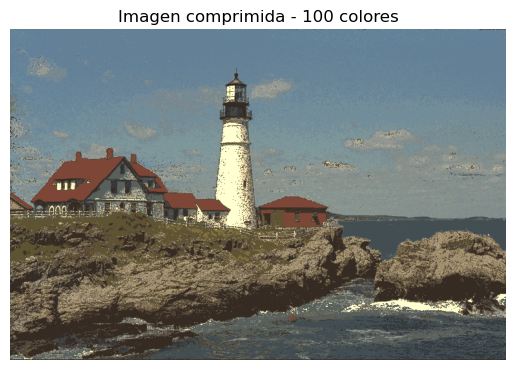


Comenzando compresión con 200 colores...
Usando 2000 píxeles de muestra para 200 colores
Duración: 00:00:13


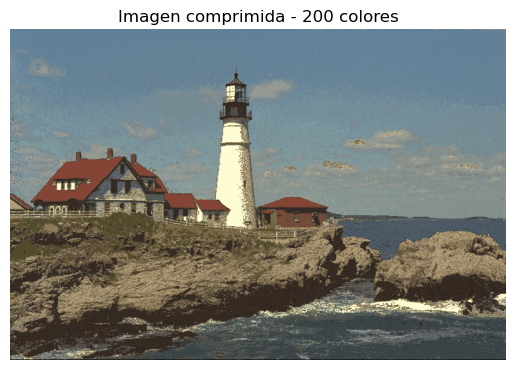


Comenzando compresión con 500 colores...
Usando 5000 píxeles de muestra para 500 colores
Duración: 00:00:37


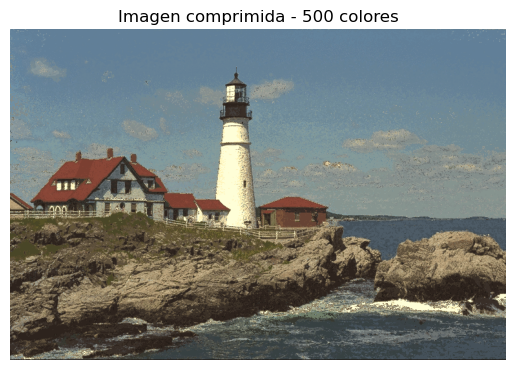


Comenzando compresión con 1000 colores...
Usando 10000 píxeles de muestra para 1000 colores
Duración: 00:01:42


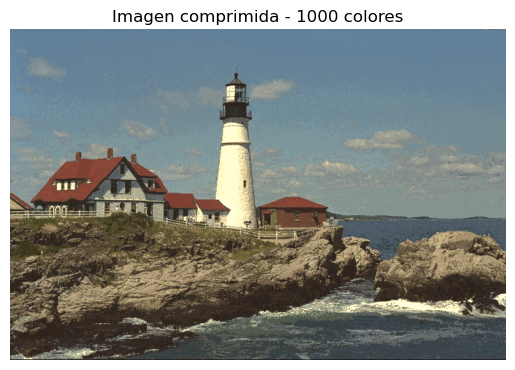


Comenzando compresión con 10000 colores...
Usando 50000 píxeles de muestra para 10000 colores
Duración: 01:29:23


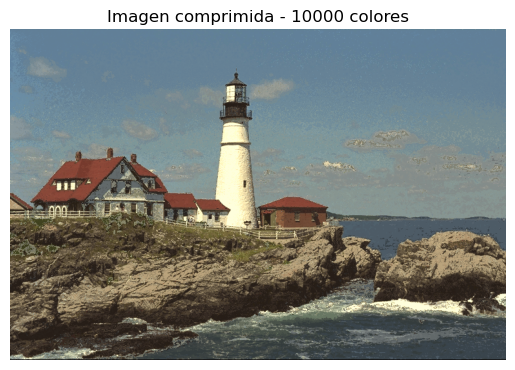

In [5]:
# 4. Ejecutar para diferentes valores de K
valores_K = [100, 200, 500, 1000, 10000]
imagenes_resultado = {}
tiempos = []

for K in valores_K:
    print(f"\nComenzando compresión con {K} colores...")
    
    inicio = time()
    comprimida = comprimir_con_GMM(pixels, K)  # ← podés ajustar la muestra si querés
    duracion = time() - inicio
    
    tiempos.append(duracion)

    print(f"Duración: {strftime('%H:%M:%S', gmtime(duracion))}")
    imsave(f"kodim21_comprimida_{K}.png", comprimida)
    imagenes_resultado[K] = comprimida

    plt.imshow(comprimida)
    plt.title(f"Imagen comprimida - {K} colores")
    plt.axis("off")
    plt.show()

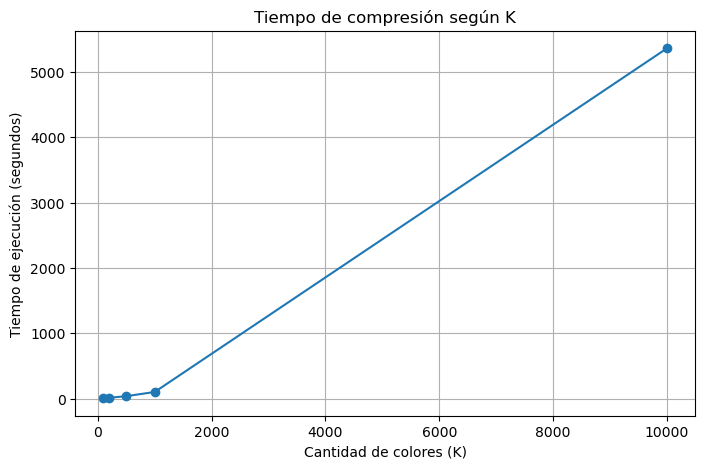

In [6]:
# 5. Gráfico de tiempo vs K
plt.figure(figsize=(8, 5))
plt.plot(valores_K, tiempos, marker='o')
plt.xlabel("Cantidad de colores (K)")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Tiempo de compresión según K")
plt.grid(True)
plt.show()

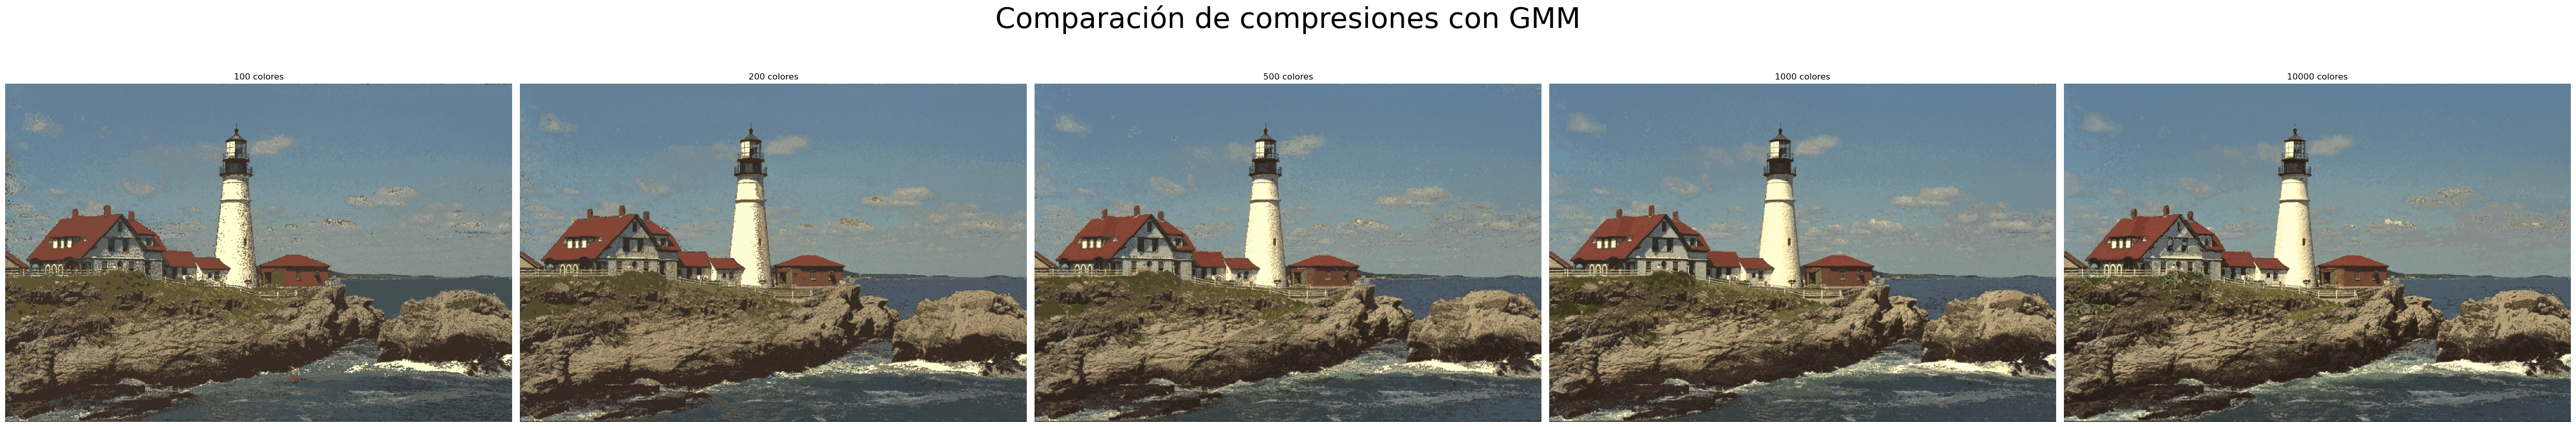

In [7]:
# 6. Grilla comparativa de imágenes
fig, axs = plt.subplots(1, len(valores_K), figsize=(50, 10))
for i, K in enumerate(valores_K):
    axs[i].imshow(imagenes_resultado[K])
    axs[i].set_title(f"{K} colores")
    axs[i].axis("off")
plt.tight_layout()
plt.suptitle("Comparación de compresiones con GMM", fontsize=40)
plt.show()